# Expecation-Maximization Algorithm

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import matplotlib.animation as animation
from tqdm import tqdm
import os
os.chdir('../')
from tgmm import GaussianMixture

np.random.seed(0)  # for reproducibility

# Suppress convergence warnings (expected since max_iter=1)
import warnings
warnings.filterwarnings('ignore', message='.*EM did not converge.*')

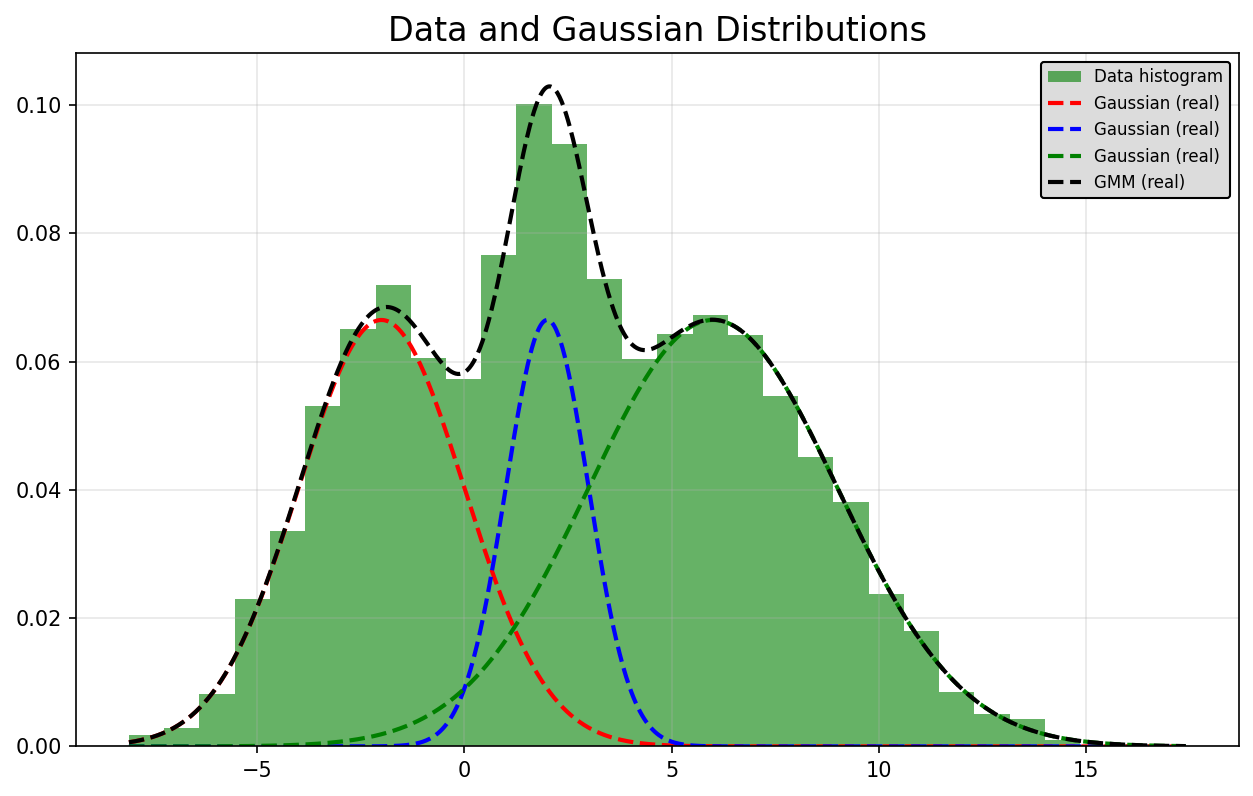

In [46]:
# Generate sample data with real means and stds
real_means = [-2, 2, 6]
real_stds = [2, 1, 3]
cluster_sizes = [2000, 1000, 3000]
data1 = np.random.normal(loc=real_means[0], scale=real_stds[0], size=cluster_sizes[0])
data2 = np.random.normal(loc=real_means[1], scale=real_stds[1], size=cluster_sizes[1])
data3 = np.random.normal(loc=real_means[2], scale=real_stds[2], size=cluster_sizes[2])
data = np.concatenate([data1, data2, data3])

# True mixing coefficients based on the actual data proportions

total_size = sum(cluster_sizes)
true_taus = [size / total_size for size in cluster_sizes]

# Plotting the histogram and Gaussian distributions
plt.figure(figsize=(10, 6), dpi=150)
plt.hist(data, bins=30, density=True, alpha=0.6, color='g', label='Data histogram')

x = np.linspace(min(data), max(data), 1000)
colors = ['r', 'b', 'g']
gaussian_real = 0

for real_mean, real_std, true_tau, color in zip(real_means, real_stds, true_taus, colors):
    plt.plot(x, true_tau * norm.pdf(x, real_mean, real_std), color=color, linestyle='--', label=f'Gaussian (real)')
    gaussian_real += true_tau * norm.pdf(x, real_mean, real_std)

# Plot GMM curves
plt.plot(x, gaussian_real, 'k--', label='GMM (real)')

plt.title('Data and Gaussian Distributions')
plt.legend()
plt.show()

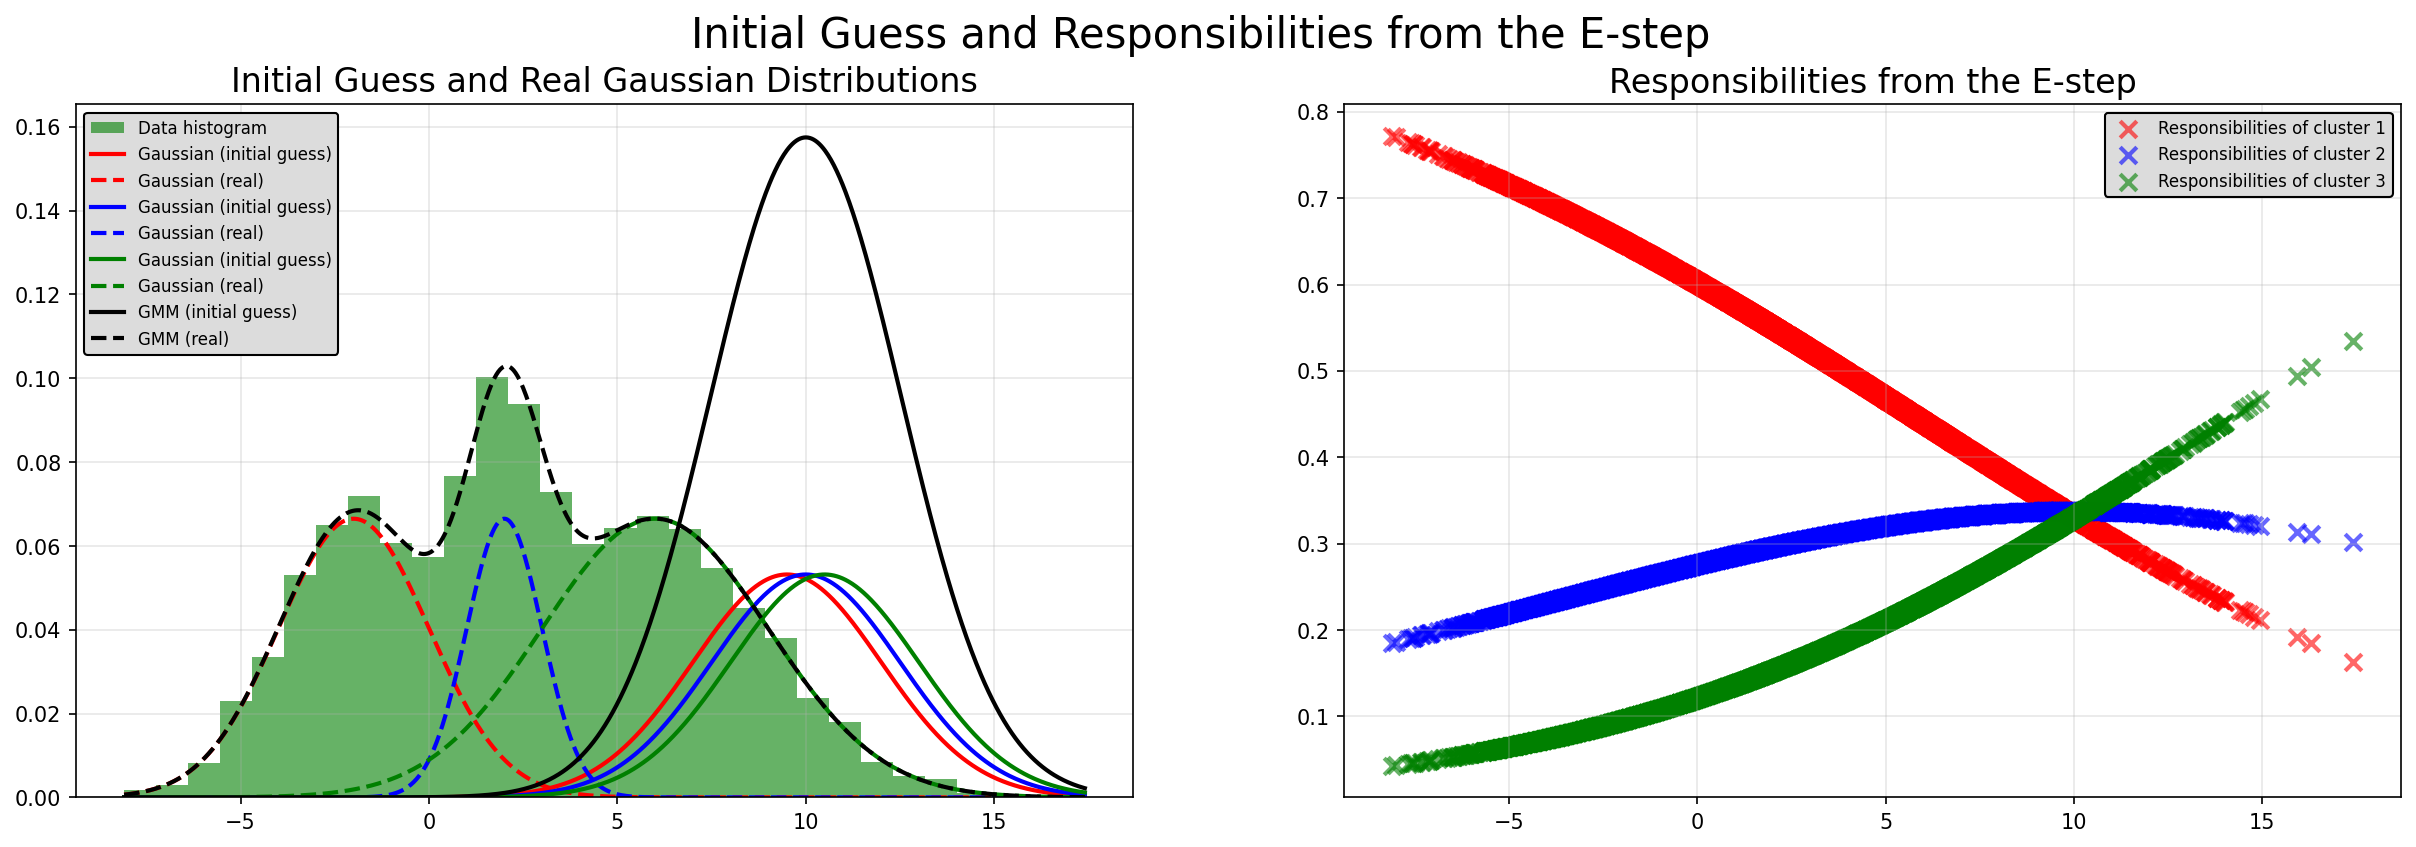

In [47]:
import torch

# Convert data to torch tensor
X_1d = torch.tensor(data, dtype=torch.float32).reshape(-1, 1)

# Initial parameters for the Gaussian Mixture Model
initial_means = torch.tensor([[9.5], [10.0], [10.5]], dtype=torch.float32)
initial_covariances = torch.tensor([[[2.5**2]], [[2.5**2]], [[2.5**2]]], dtype=torch.float32)
initial_weights = torch.tensor([0.33, 0.33, 0.33], dtype=torch.float32)

# Create GMM with initial parameters
gmm_init = GaussianMixture(
    n_features=1, 
    n_components=3, 
    covariance_type='full',
    init_means=initial_means,
    init_covariances=initial_covariances,
    init_weights=initial_weights,
    device='cpu'
)

# Initialize without fitting
gmm_init._allocate_parameters(X_1d, set_random_state=False)

# Perform E-step with initial parameters
r, _ = gmm_init._e_step(X_1d)

# Plotting the initial guess and real Gaussians
fig, axs = plt.subplots(1, 2, figsize=(20, 6), dpi=150)

# Left subplot: Initial guess and real Gaussians
axs[0].hist(data, bins=30, density=True, alpha=0.6, color='g', label='Data histogram')
x = np.linspace(min(data), max(data), 1000)
colors = ['r', 'b', 'g']
gaussian_real = 0
gaussian_est = 0

for i, (mean, cov, weight, real_mean, real_std, true_tau, color) in enumerate(
    zip(gmm_init.means_, gmm_init.covariances_, gmm_init.weights_, real_means, real_stds, true_taus, colors)):
    std = torch.sqrt(cov[0, 0]).item()
    mean_val = mean[0].item()
    
    # Plot initial guess Gaussian
    axs[0].plot(x, weight.item() * norm.pdf(x, mean_val, std), color=color, linestyle='-', label=f'Gaussian (initial guess)')
    gaussian_est += weight.item() * norm.pdf(x, mean_val, std)
    
    # Plot real Gaussian using true mixing coefficient
    axs[0].plot(x, true_tau * norm.pdf(x, real_mean, real_std), color=color, linestyle='--', label=f'Gaussian (real)')
    gaussian_real += true_tau * norm.pdf(x, real_mean, real_std)

# Plot GMM curves
axs[0].plot(x, gaussian_est, 'k-', label='GMM (initial guess)')
axs[0].plot(x, gaussian_real, 'k--', label='GMM (real)')
axs[0].set_title('Initial Guess and Real Gaussian Distributions')
axs[0].legend()

# Right subplot: Membership probabilities from the E-step
colors = ['r', 'b', 'g']
for i in range(3):
    axs[1].scatter(data, r[:, i].cpu().numpy(), color=colors[i], label=f'Responsibilities of cluster {i+1}', alpha=0.6, marker='x')

axs[1].set_title('Responsibilities from the E-step')
axs[1].legend()

#title
plt.suptitle('Initial Guess and Responsibilities from the E-step')

plt.show()

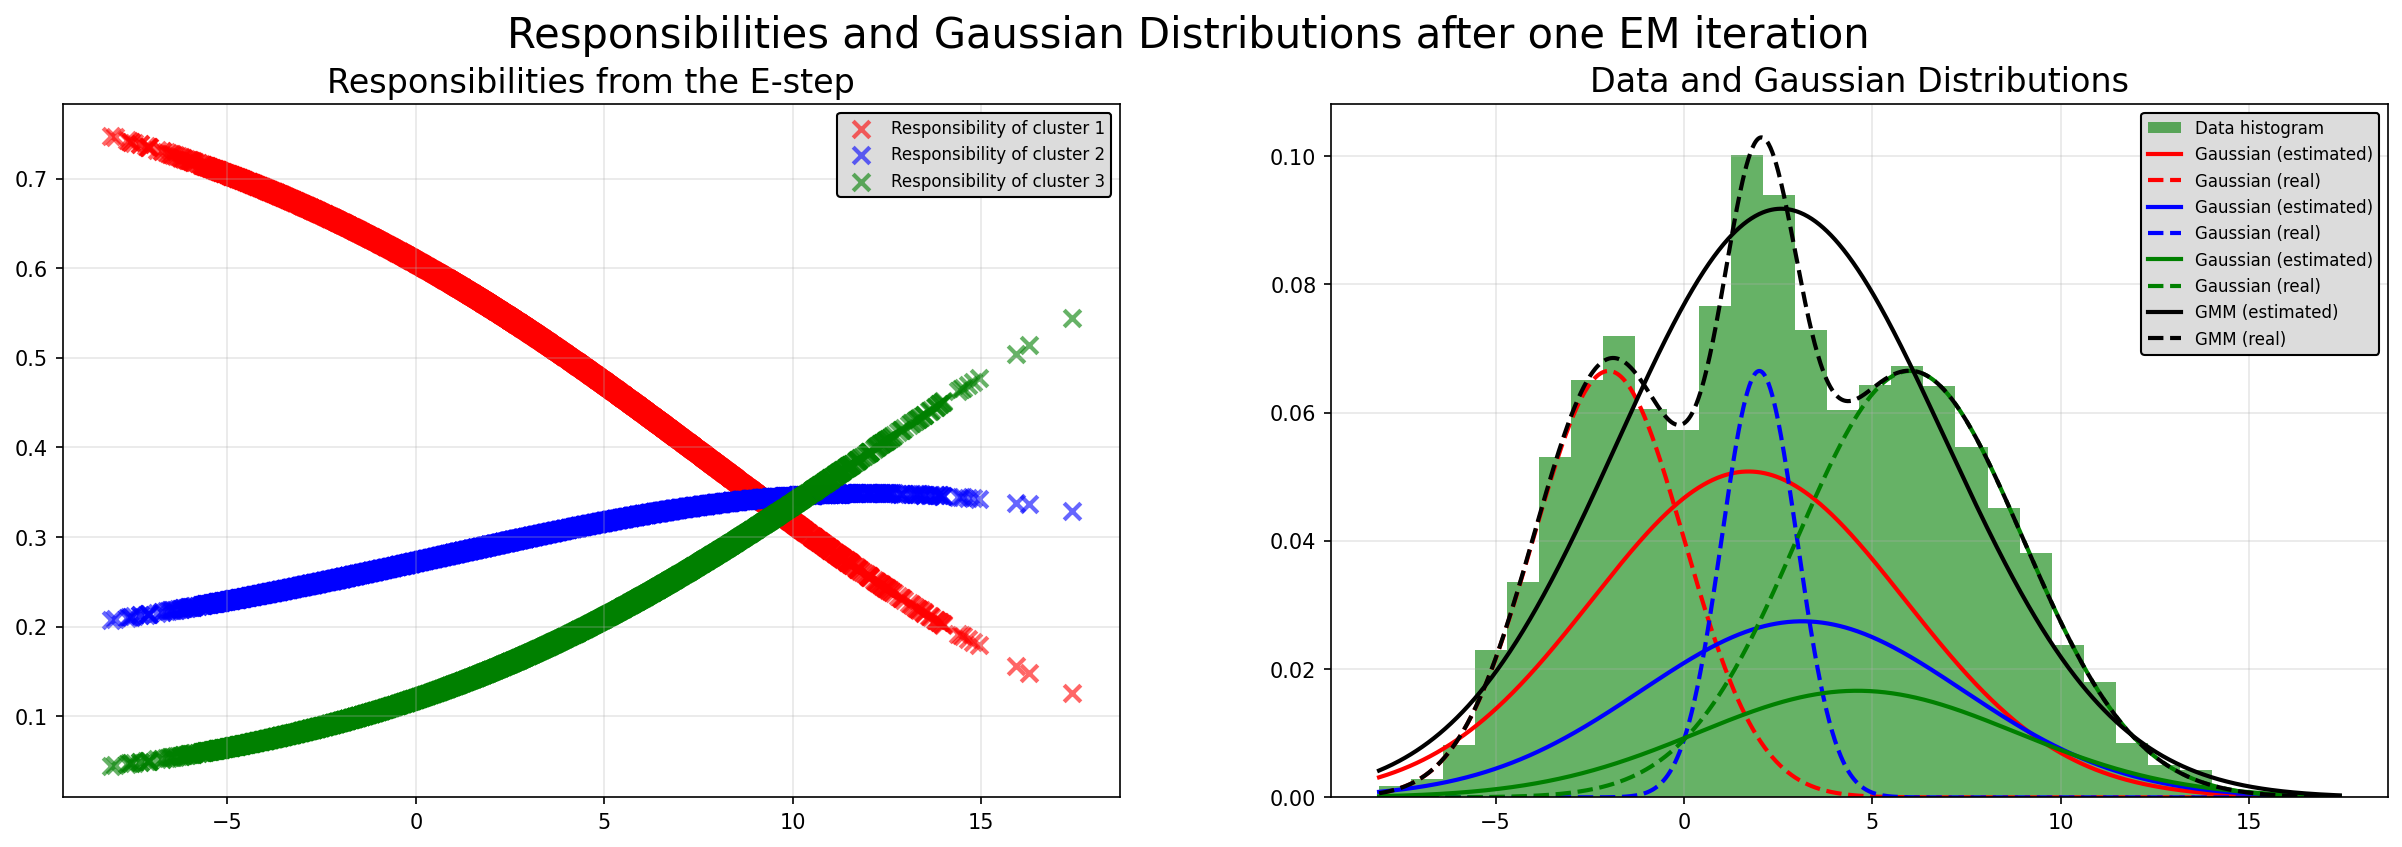

In [48]:
# Create a fresh GMM and perform one EM iteration
gmm_one_iter = GaussianMixture(
    n_features=1, 
    n_components=3, 
    covariance_type='full',
    init_means=initial_means,
    init_covariances=initial_covariances,
    init_weights=initial_weights,
    device='cpu',
    max_iter=1  # Only one iteration
)

# Fit for one iteration
gmm_one_iter.fit(X_1d)

# Get responsibilities after one iteration
r, _ = gmm_one_iter._e_step(X_1d)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(20, 6), dpi=150)

# Second subplot: Membership probabilities
colors = ['r', 'b', 'g']
for i in range(3):
    axs[0].scatter(data, r[:, i].cpu().numpy(), color=colors[i], label=f'Responsibility of cluster {i+1}', alpha=0.6, marker='x')

axs[0].set_title('Responsibilities from the E-step')
axs[0].legend()

axs[1].hist(data, bins=30, density=True, alpha=0.6, color='g', label='Data histogram')

x = np.linspace(min(data), max(data), 1000)
colors = ['r', 'b', 'g']
gaussian_est = 0
gaussian_real = 0

for i, (mean, cov, weight, real_mean, real_std, true_tau, color) in enumerate(
    zip(gmm_one_iter.means_, gmm_one_iter.covariances_, gmm_one_iter.weights_, real_means, real_stds, true_taus, colors)):
    std = torch.sqrt(cov[0, 0]).item()
    mean_val = mean[0].item()
    
    # Plot estimated Gaussian
    axs[1].plot(x, weight.item() * norm.pdf(x, mean_val, std), color=color, linestyle='-', label=f'Gaussian (estimated)')
    gaussian_est += weight.item() * norm.pdf(x, mean_val, std)
    
    # Plot real Gaussian using true mixing coefficient
    axs[1].plot(x, true_tau * norm.pdf(x, real_mean, real_std), color=color, linestyle='--', label=f'Gaussian (real)')
    gaussian_real += true_tau * norm.pdf(x, real_mean, real_std)

# Plot GMM curves
axs[1].plot(x, gaussian_est, 'k-', label='GMM (estimated)')
axs[1].plot(x, gaussian_real, 'k--', label='GMM (real)')

axs[1].set_title('Data and Gaussian Distributions')
axs[1].legend()
# title
fig.suptitle('Responsibilities and Gaussian Distributions after one EM iteration')
plt.show()

100%|██████████| 1000/1000 [00:09<00:00, 104.32it/s]


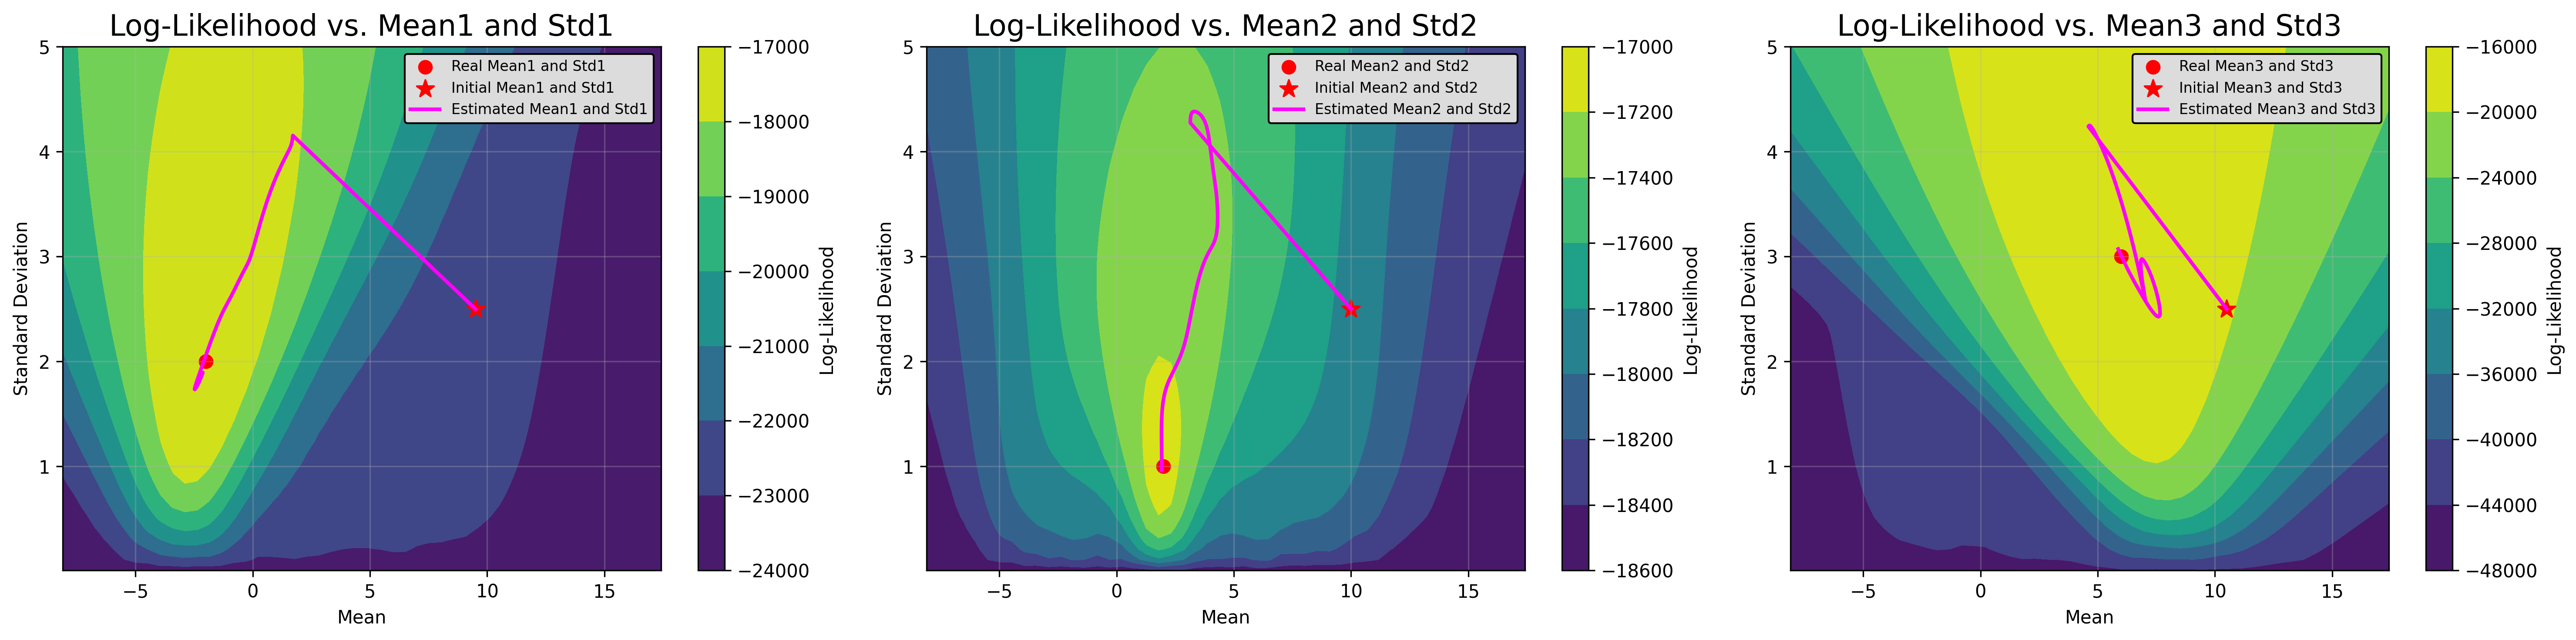

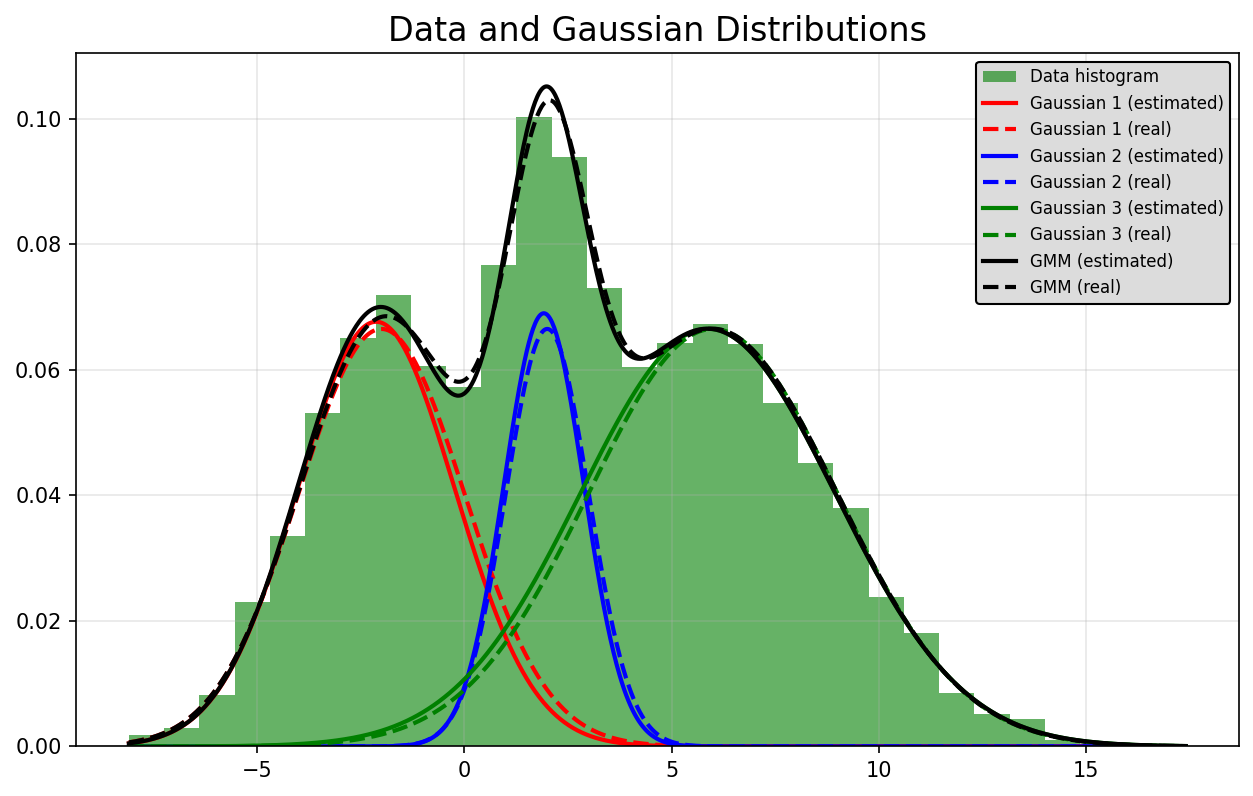

In [49]:
num_steps = 1000
#num_steps = 10 #for testing

# Create GMM and fit with full EM
gmm_full = GaussianMixture(
    n_features=1, 
    n_components=3, 
    covariance_type='full',
    init_means=initial_means,
    init_covariances=initial_covariances,
    init_weights=initial_weights,
    device='cpu',
    max_iter=num_steps,
    verbose=False
)

# Track parameters over iterations
means = np.zeros((num_steps+1, 3))
stds = np.zeros((num_steps+1, 3))
taus = np.zeros((num_steps+1, 3))

means[0] = initial_means.squeeze().numpy()
stds[0] = [2.5, 2.5, 2.5]
taus[0] = initial_weights.numpy()

# Fit one iteration at a time to track progress
for step in tqdm(range(num_steps)):
    # Create a new GMM for this iteration
    gmm_step = GaussianMixture(
        n_features=1, 
        n_components=3, 
        covariance_type='full',
        init_means=torch.tensor(means[step].reshape(-1, 1), dtype=torch.float32),
        init_covariances=torch.tensor([[[stds[step][i]**2]] for i in range(3)], dtype=torch.float32),
        init_weights=torch.tensor(taus[step], dtype=torch.float32),
        device='cpu',
        max_iter=1
    )
    
    gmm_step.fit(X_1d)
    
    # Store parameters
    means[step+1] = gmm_step.means_.squeeze().cpu().numpy()
    stds[step+1] = torch.sqrt(gmm_step.covariances_[:, 0, 0]).cpu().numpy()
    taus[step+1] = gmm_step.weights_.cpu().numpy()
    
    if gmm_step.converged_:
        break

# Use the last fitted GMM for visualization
gmm_full = gmm_step

# Range of parameter values for plotting
mean_range = np.linspace(min(data), max(data), 50)
std_range = np.linspace(0.01, 5, 50)

# Log likelihood function for visualization
def log_likelihood(data, means_np, stds_np, taus_np):
    likelihood = np.zeros((data.shape[0], len(means_np)))
    for i in range(len(means_np)):
        likelihood[:, i] = norm.pdf(data, means_np[i], stds_np[i])
    total_likelihood = np.dot(likelihood, taus_np)
    return np.sum(np.log(total_likelihood))

# Compute log-likelihood for different parameter values
log_likelihoods_mean1_std1 = np.zeros((len(std_range), len(mean_range)))
log_likelihoods_mean2_std2 = np.zeros((len(std_range), len(mean_range)))
log_likelihoods_mean3_std3 = np.zeros((len(std_range), len(mean_range)))

for i, m in enumerate(mean_range):
    for j, s in enumerate(std_range):
        means_1 = [m, means[-1, 1], means[-1, 2]]
        stds_1 = [s, stds[-1, 1], stds[-1, 2]]
        means_2 = [means[-1, 0], m, means[-1, 2]]
        stds_2 = [stds[-1, 0], s, stds[-1, 2]]
        means_3 = [means[-1, 0], means[-1, 1], m]
        stds_3 = [stds[-1, 0], stds[-1, 1], s]
        taus_ll = [taus[-1, 0], taus[-1, 1], taus[-1, 2]]

        log_likelihoods_mean1_std1[j, i] = log_likelihood(data, means_1, stds_1, taus_ll)
        log_likelihoods_mean2_std2[j, i] = log_likelihood(data, means_2, stds_2, taus_ll)
        log_likelihoods_mean3_std3[j, i] = log_likelihood(data, means_3, stds_3, taus_ll)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# Mean1 and Std1
cs = axs[0].contourf(mean_range, std_range, log_likelihoods_mean1_std1, cmap='viridis')
cbar = fig.colorbar(cs, ax=axs[0])
cbar.ax.set_ylabel('Log-Likelihood')
axs[0].set_title('Log-Likelihood vs. Mean1 and Std1')
axs[0].set_ylabel('Standard Deviation')
axs[0].set_xlabel('Mean')
axs[0].scatter(real_means[0], real_stds[0], color='red', label='Real Mean1 and Std1', s=50, marker='o')
axs[0].scatter(means[0,0], stds[0,0], color='red', label='Initial Mean1 and Std1',s=100, marker='*')
axs[0].plot(means[:,0], stds[:,0], color = 'magenta', label='Estimated Mean1 and Std1')
axs[0].legend()

# Mean2 and Std2
cs = axs[1].contourf(mean_range, std_range, log_likelihoods_mean2_std2, cmap='viridis')
cbar = fig.colorbar(cs, ax=axs[1])
cbar.ax.set_ylabel('Log-Likelihood')
axs[1].set_title('Log-Likelihood vs. Mean2 and Std2')
axs[1].set_ylabel('Standard Deviation')
axs[1].set_xlabel('Mean')
axs[1].scatter(real_means[1], real_stds[1], color='red', label='Real Mean2 and Std2', s=50, marker='o')
axs[1].scatter(means[0,1], stds[0,1], color='red', label='Initial Mean2 and Std2',s=100, marker='*')
axs[1].plot(means[:,1], stds[:,1], color = 'magenta', label='Estimated Mean2 and Std2')
axs[1].legend()

# Mean3 and Std3
cs = axs[2].contourf(mean_range, std_range, log_likelihoods_mean3_std3, cmap='viridis')
cbar = fig.colorbar(cs, ax=axs[2])
cbar.ax.set_ylabel('Log-Likelihood')
axs[2].set_title('Log-Likelihood vs. Mean3 and Std3')
axs[2].set_ylabel('Standard Deviation')
axs[2].set_xlabel('Mean')
axs[2].scatter(real_means[2], real_stds[2], color='red', label='Real Mean3 and Std3', s=50, marker='o')
axs[2].scatter(means[0,2], stds[0,2], color='red', label='Initial Mean3 and Std3',s=100, marker='*')
axs[2].plot(means[:,2], stds[:,2], color = 'magenta', label='Estimated Mean3 and Std3')
axs[2].legend()

plt.tight_layout()
plt.show()

# plot histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=150)
ax.hist(data, bins=30, density=True, alpha=0.6, color='g', label='Data histogram')
gaussian_est = 0
gaussian_real = 0
x = np.linspace(min(data), max(data), 1000)
colors = ['r', 'b', 'g']

for i, (mean, cov, weight, real_mean, real_std, color) in enumerate(
    zip(gmm_full.means_, gmm_full.covariances_, gmm_full.weights_, real_means, real_stds, colors)):
    std = torch.sqrt(cov[0, 0]).item()
    mean_val = mean[0].item()
    
    ax.plot(x, weight.item() * norm.pdf(x, mean_val, std), label=f'Gaussian {i+1} (estimated)', color=color, linestyle='-')
    ax.plot(x, true_taus[i] * norm.pdf(x, real_mean, real_std), label=f'Gaussian {i+1} (real)', color=color, linestyle='--')
    gaussian_est += weight.item() * norm.pdf(x, mean_val, std)
    gaussian_real += true_taus[i] * norm.pdf(x, real_mean, real_std)

# plot GMM
ax.plot(x, gaussian_est, 'k-', label='GMM (estimated)')
ax.plot(x, gaussian_real, 'k--', label='GMM (real)')

ax.set_title('Data and Gaussian Distributions')
ax.legend()
plt.show()

## 2D Example

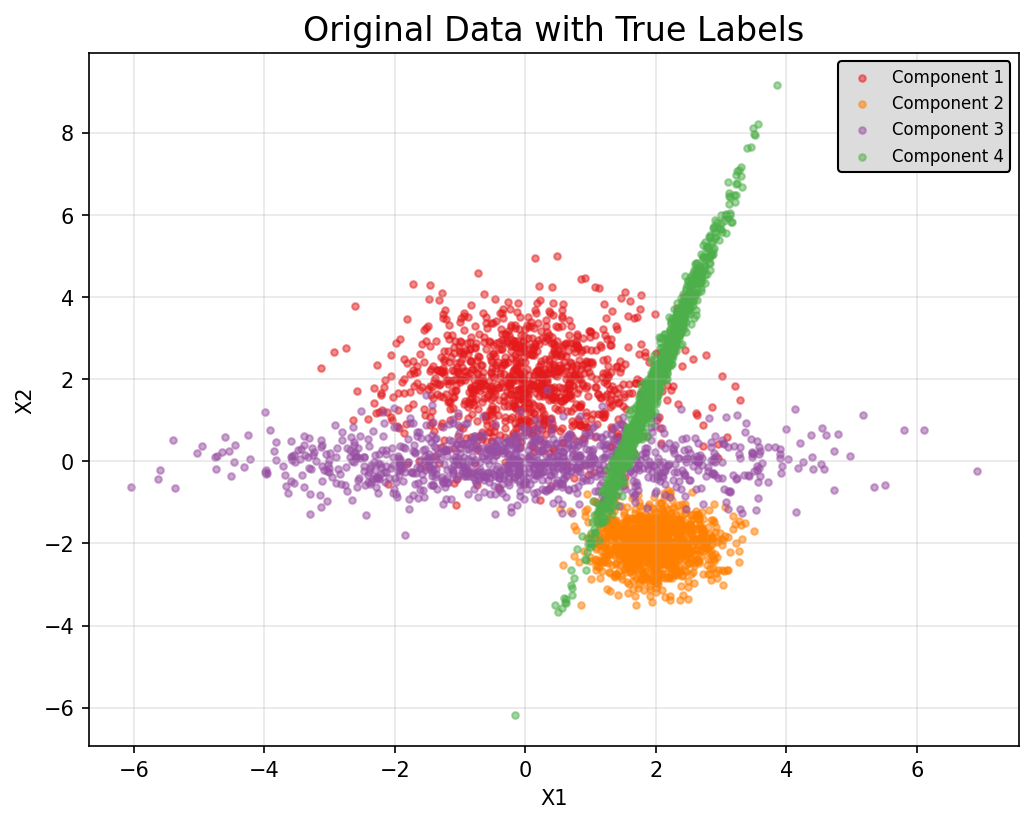

In [50]:
import torch
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal
import numpy as np

# Create a more complex 2D dataset with four blobs
n_samples = [1000, 1000, 1000, 1000]
centers = [np.array([0, 2]),
           np.array([2, -2]),
           np.array([0, 0]),
           np.array([2, 2])]
covs = [
    1.0 * np.eye(2),                    # spherical covariance
    0.5 * np.eye(2),                    # spherical covariance, fewer points
    np.array([[2, 0], [0, 0.5]]),       # diagonal covariance
    np.array([[0.2, 0.5], [0.5, 2]])    # full covariance
]

components = []
for n, center, cov in zip(n_samples, centers, covs):
    samples = np.dot(np.random.randn(n, 2), cov) + center
    components.append(samples)

X = np.vstack(components)
labels = np.concatenate([i * np.ones(n) for i, n in enumerate(n_samples)])
legend_labels = [f'Component {i+1}' for i in range(len(n_samples))]

n_features = X.shape[1]
n_components = len(n_samples)

# Convert to tensor (if needed for further processing)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X = torch.tensor(X, dtype=torch.float32, device=device)

# Initialize means for 4 components
means_init = torch.tensor([[-1.0, 5.0], [0.0, 5.0], [1.0, 5.0], [2.0, 5.0]], device=device)

# Plot the original data
plt.figure(figsize=(8, 6), dpi=150)
colors_data = ['#e41a1c', '#ff7f00', '#984ea3', '#4daf4a']
for i in range(len(n_samples)):
    component_mask = labels == i
    plt.scatter(X[component_mask, 0].cpu(), X[component_mask, 1].cpu(), 
                c=colors_data[i], s=10, alpha=0.5, label=legend_labels[i])
plt.title('Original Data with True Labels')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

In [51]:
# Function to generate a plot for a specific iteration
def plot_2d_gmm_resp(gmm, X, responsibilities, iteration, fig, axs, row, gmm_means):
    colors = ['#e41a1c', '#ff7f00', '#984ea3', '#4daf4a']

    # Plot responsibilities for each cluster as line plot
    for i in range(gmm.n_components):
        axs[row, 0].plot(responsibilities[:, i].cpu().numpy(), label=f'Cluster {i+1}', color=colors[i], marker='x', linestyle='None', alpha=0.5)
    axs[row, 0].legend()  # Add legend
    axs[row, 0].set_title(f'Responsibilities after {iteration} Iteration(s)')
    axs[row, 0].set_xlabel('Data Point Index')
    axs[row, 0].set_ylabel('Probability')

    # Assign the correct colors based on the cluster with the highest responsibility
    cluster_assignments = responsibilities.cpu().max(dim=1)[1]
    assigned_colors = [colors[cluster] for cluster in cluster_assignments]

    # Scatter plot of the responsibilities using the correct colors
    axs[row, 1].scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=assigned_colors, s=10, alpha=0.5)
    axs[row, 1].set_title(f'Responsibilities after {iteration} Iteration(s)')
    axs[row, 1].set_xlabel('X1')
    axs[row, 1].set_ylabel('X2')

    # Scatter plot of data points with Gaussian components
    axs[row, 2].scatter(X[:, 0].cpu(), X[:, 1].cpu(), c='gray', s=5, label='Data Points', alpha=0.5)

    for i in range(gmm.n_components):
        mean = gmm.means_[i].cpu()
        cov = gmm.covariances_[i].cpu()

        eigvals, eigvecs = torch.linalg.eigh(cov)
        angle = torch.atan2(eigvecs[1, 0], eigvecs[0, 0])

        # Create an ellipse representing the covariance
        width, height = (2 * torch.sqrt(eigvals).cpu().numpy())
        ellipse = plt.matplotlib.patches.Ellipse(mean, width, height, angle=angle.item() * 180.0 / torch.pi, edgecolor=colors[i], facecolor='none', lw=2)
        axs[row, 2].add_patch(ellipse)
        axs[row, 2].plot([mean.cpu()[i][0].item() for mean in gmm_means], 
                         [mean.cpu()[i][1].item() for mean in gmm_means], 
                         color=colors[i], linestyle='--')
        axs[row, 2].scatter(gmm_means[-1].cpu()[i][0].item(), gmm_means[-1].cpu()[i][1].item(), color=colors[i], marker='o', s=50)


    # Plot initial means with color markers
    for i in range(gmm.n_components):
        axs[row, 2].scatter(gmm_means[0].cpu()[i][0].item(), gmm_means[0].cpu()[i][1].item(), color=colors[i], marker='x', s=100)
    
    axs[row, 2].set_title(f'GMM after {iteration} Iteration(s)')
    axs[row, 2].set_xlabel('X1')
    axs[row, 2].set_ylabel('X2')
    
    axs[row, 2].scatter([], [], color='black', marker='x', s=100, label='Initial Means')
    axs[row, 2].scatter([], [], color='black', marker='o', s=50, label='Final Means')
    axs[row, 2].plot([], [], color='black', linestyle='-', label='Gaussian Components')
    axs[row, 2].plot([], [], color='black', linestyle='--', label='Trace of means')
    axs[row, 2].legend()


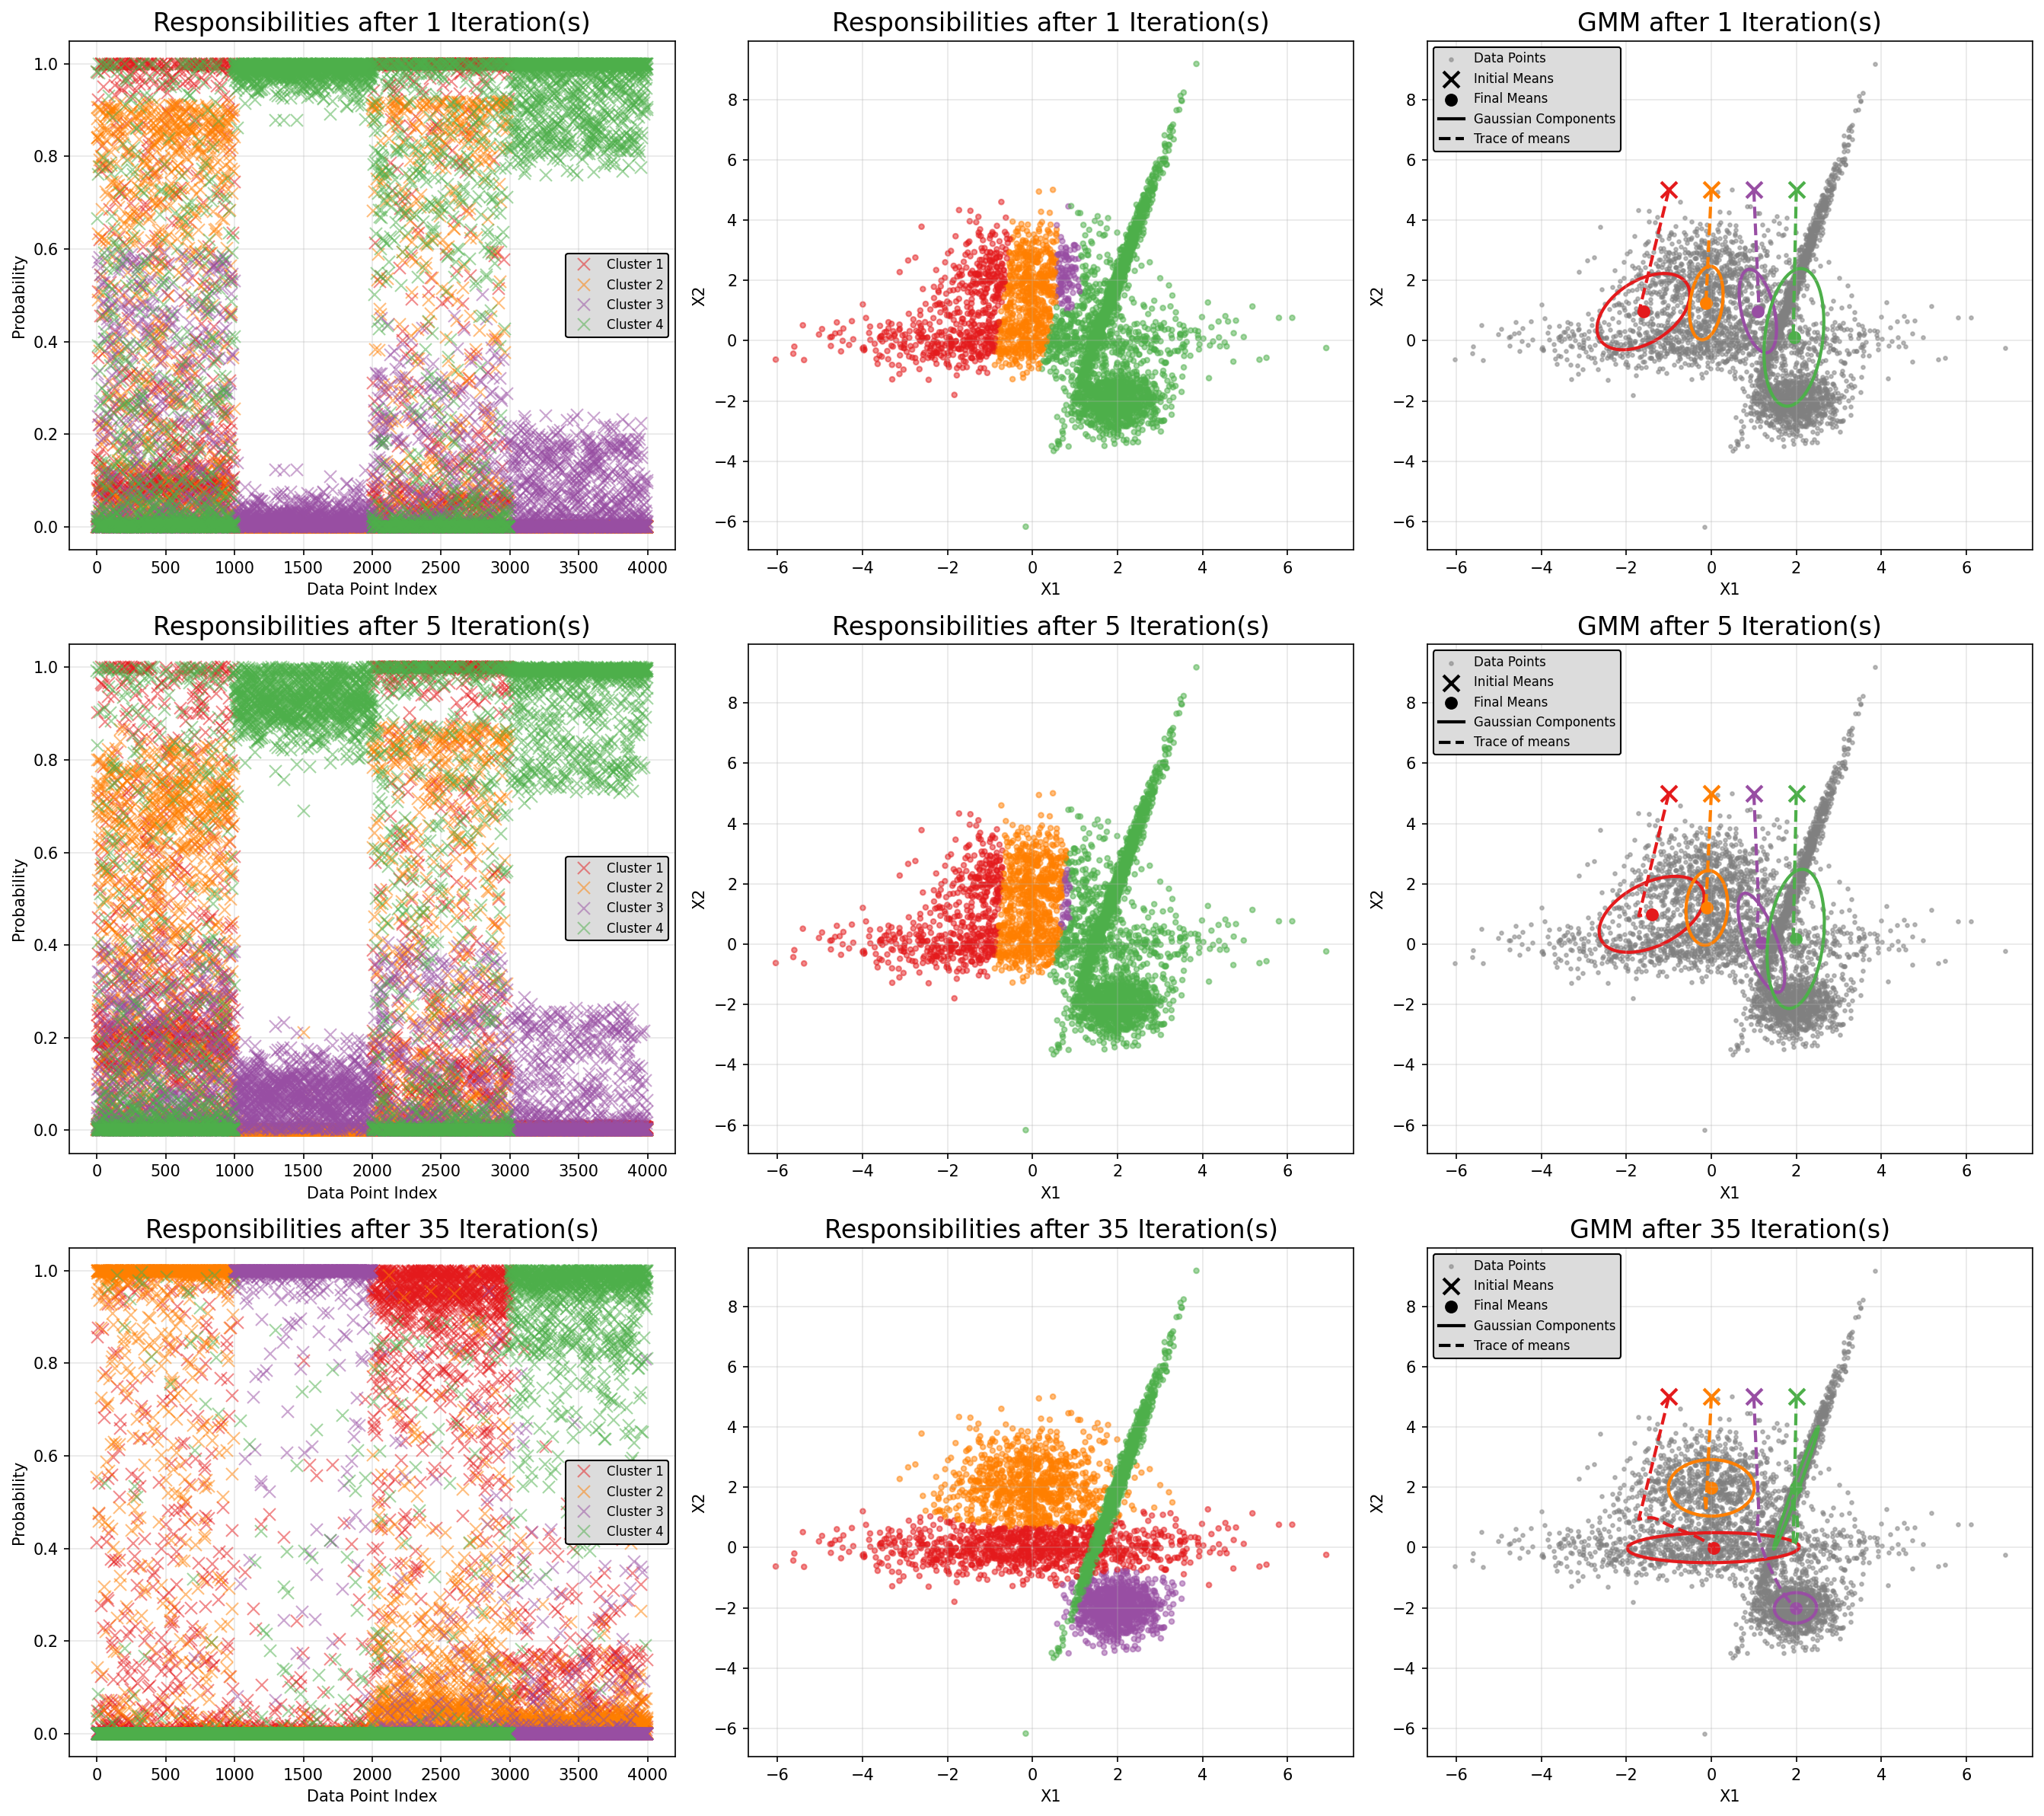

In [52]:
fig, axs = plt.subplots(3, 3, figsize=(18, 16), dpi=150)

gmm_means = [means_init]
n_plot = 0

for i in range(1000):
    gmm = GaussianMixture(n_features=2, n_components=4, covariance_type='full', init_means=means_init, device=device, tol=1e-6)
    if i > 0:
        gmm.fit(X, max_iter=i)
    else:
        # For i=0, allocate parameters but don't run EM
        gmm._allocate_parameters(X)
    responsibilities, _ = gmm._e_step(X)
    gmm._m_step(X, responsibilities)
    gmm_means.append(gmm.means_)
    if i == 1 or i == 5 or gmm.converged_:
        plot_2d_gmm_resp(gmm, X, responsibilities, i, fig, axs, n_plot, gmm_means)
        n_plot += 1
        if gmm.converged_:
            break

plt.tight_layout()
plt.show()